In [4]:
import itertools
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix, Statevector

def measurement_feedback_operator(state, L, pm, pf):
    """Generate the measurement and feedback operator for the system."""
    I = np.eye(2)
    X = np.array([[0, 1], [1, 0]])
    P0 = np.array([[1, 0], [0, 0]])
    P1 = np.array([[0, 0], [0, 1]])

    state_density = state
    full_operator = np.eye(2**L, dtype=complex)
    names = ['I'] * L  # Initialize names for all qubits

    for i in range(L):
        # Create projection operators for the full state
        P0_full = np.kron(np.eye(2**i), np.kron(P0, np.eye(2**(L-i-1))))
        P1_full = np.kron(np.eye(2**i), np.kron(P1, np.eye(2**(L-i-1))))

        prob_0 = np.real(np.trace(P0_full @ state_density @ P0_full))
        prob_1 = np.real(np.trace(P1_full @ state_density @ P1_full))

        # Normalize probabilities
        prob_sum = prob_0 + prob_1
        if prob_sum > 0:
            prob_0 /= prob_sum
            prob_1 /= prob_sum

        if np.random.rand() < pm:
            if np.random.rand() < prob_0:
                full_operator = full_operator @ P0_full
                names[i] = 'P0'
            else:
                full_operator = full_operator @ P1_full
                names[i] = 'P1'
                if np.random.rand() < pf:
                    feedback_full = np.kron(np.eye(2**i), np.kron(X @ P1, np.eye(2**(L-i-1))))
                    full_operator = full_operator @ feedback_full
                    names[i] = 'XP1'

    full_name = ', '.join(names)
    return full_operator, full_name

def compute_expected_probabilities(L, pm, pf, p0_list, p1_list):
    """Compute the expected probabilities for measurement and feedback outcomes for L qubits."""
    outcomes = ['I', 'P0', 'P1', 'XP1']
    expected_probs = {}

    for outcome in itertools.product(outcomes, repeat=L):
        prob = 1.0
        for i, op in enumerate(outcome):
            p0 = p0_list[i]
            p1 = p1_list[i]
            if op == 'I':
                prob *= (1 - pm)
            elif op == 'P0':
                prob *= pm * p0
            elif op == 'P1':
                prob *= pm * p1 * (1 - pf)
            elif op == 'XP1':
                prob *= pm * p1 * pf
        expected_probs[', '.join(outcome)] = prob

    return expected_probs

def maximally_entangled_state(L):
    """Generate a maximally entangled state (GHZ state) for L qubits."""
    qc = QuantumCircuit(L)
    
    # Apply a Hadamard gate to the first qubit
    qc.h(0)
    
    # Apply CNOT gates to create entanglement
    for i in range(1, L):
        qc.cx(0, i)
    
    # Get the statevector of the GHZ state
    state = Statevector.from_instruction(qc)
    
    return DensityMatrix(state).data

def round_to_significant_figures(value, sig_figs):
    """Round a value to the specified number of significant figures."""
    if value == 0:
        return 0
    else:
        return round(value, sig_figs - int(np.floor(np.log10(abs(value)))) - 1)

def test_measurement_feedback_operator(L, pm, pf, num_samples=10000):
    """Test the statistics of the measurement and feedback operator."""
    # initial_state = generalized_bell_state(L)
    # initial_state = DensityMatrix.from_label('1' * L).data
    initial_state = maximally_entangled_state(L)
    
    # Measurement probabilities for each qubit
    p0_list = []
    p1_list = []
    for i in range(L):
        P0_full = np.kron(np.eye(2**i), np.kron(np.array([[1, 0], [0, 0]]), np.eye(2**(L-i-1))))
        P1_full = np.kron(np.eye(2**i), np.kron(np.array([[0, 0], [0, 1]]), np.eye(2**(L-i-1))))
        p0 = np.real(np.trace(P0_full @ initial_state @ P0_full))
        p1 = np.real(np.trace(P1_full @ initial_state @ P1_full))
        p0_list.append(p0 / (p0 + p1))
        p1_list.append(p1 / (p0 + p1))

    # Debug information for probabilities
    print("Individual qubit probabilities (p0 and p1):")
    for i in range(L):
        print(f"Qubit {i}: p0 = {p0_list[i]:.3f}, p1 = {p1_list[i]:.3f}")

    # Measure the operator statistics
    operator_counts = {}
    for _ in range(num_samples):
        _, name = measurement_feedback_operator(initial_state, L, pm, pf)
        if name in operator_counts:
            operator_counts[name] += 1
        else:
            operator_counts[name] = 1

    # Convert counts to probabilities
    total_counts = sum(operator_counts.values())
    measured_probs = {k: v / total_counts for k, v in operator_counts.items()}

    # Compute expected probabilities
    expected_probs = compute_expected_probabilities(L, pm, pf, p0_list, p1_list)

    # Display the results side by side
    print(f"{'Name':<30} {'Measured Probability':<20} {'Expected Probability':<20} {'Percentage Discrepancy':<20}")
    for key in set(measured_probs.keys()).union(set(expected_probs.keys())):
        measured = round_to_significant_figures(measured_probs.get(key, 0), 3)
        expected = round_to_significant_figures(expected_probs.get(key, 0), 3)
        if expected != 0:
            discrepancy = abs(measured - expected) / expected * 100
        else:
            discrepancy = 0 if measured == 0 else float('inf')
        print(f"{key:<30} {measured:<20.3f} {expected:<20.3f} {discrepancy:<20.3f}")

# Test parameters
L = 2  # Number of qubits
pm = 0.5  # Measurement rate
pf = 0.5  # Feedback rate
num_samples = 10000  # Number of samples

# Run the test
test_measurement_feedback_operator(L, pm, pf, num_samples)

Individual qubit probabilities (p0 and p1):
Qubit 0: p0 = 0.500, p1 = 0.500
Qubit 1: p0 = 0.500, p1 = 0.500
Name                           Measured Probability Expected Probability Percentage Discrepancy
P0, I                          0.129                0.125                3.200               
I, P0                          0.124                0.125                0.800               
P1, P1                         0.014                0.016                11.538              
P1, XP1                        0.014                0.016                10.897              
P0, XP1                        0.030                0.031                4.487               
XP1, P1                        0.015                0.016                6.410               
I, P1                          0.063                0.062                0.960               
I, I                           0.255                0.250                2.000               
I, XP1                         0.060        

Final measurement results for L=4:
{'0000': 100.0}
Final measurement results for L=6:
{'000000': 100.0}


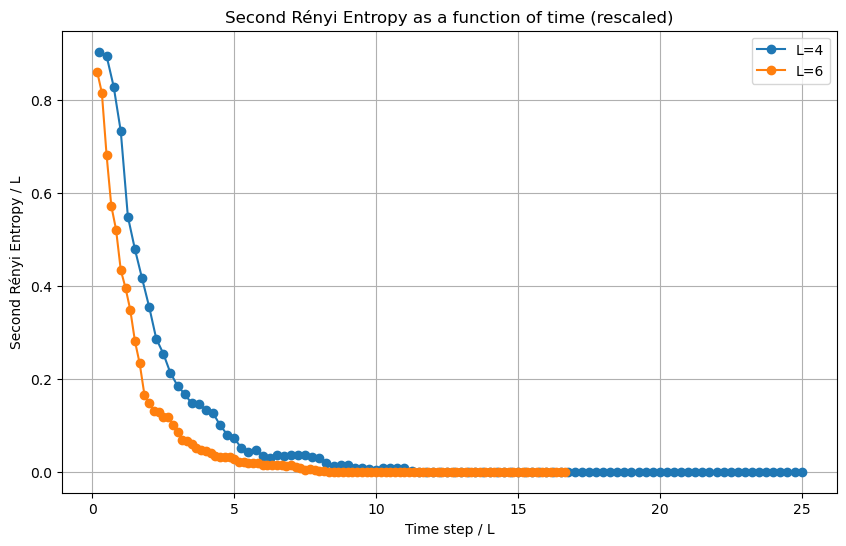

In [26]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.quantum_info import random_unitary, Statevector, DensityMatrix
import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram
from IPython.display import display
from collections import Counter

def block_diagonal_unitary():
    """Generate a block-diagonal unitary matrix that leaves |↑↑⟩ invariant and acts randomly on |↑↓⟩, |↓↑⟩, |↓↓⟩."""
    U3 = random_unitary(3).data  # Haar-random unitary in the 3x3 subspace
    U = np.eye(4, dtype=complex)
    U[1:, 1:] = U3  # Applying the random unitary to the |↑↓⟩, |↓↑⟩, |↓↓⟩ states
    return U

def apply_custom_unitaries(qc, qreg, L, step):
    """Apply custom block-diagonal unitaries on the system in a zigzag pattern."""
    if step % 2 == 0:
        # Apply unitaries to pairs (0-1, 2-3, 4-5, ...)
        for i in range(0, L-1, 2):
            U = block_diagonal_unitary()
            qc.unitary(U, [qreg[i], qreg[i+1]], label='U')
    else:
        # Apply unitaries to pairs (1-2, 3-4, 5-0, ...)
        for i in range(1, L, 2):
            U = block_diagonal_unitary()
            if i == L-1:
                qc.unitary(U, [qreg[i], qreg[0]], label='U')
            else:
                qc.unitary(U, [qreg[i], qreg[i+1]], label='U')

def measure_and_update_state(state, qreg, pm):
    """Perform measurements probabilistically and update the state vector accordingly."""
    measured_indices = []
    measurements = {}

    for i in range(len(qreg)):
        if np.random.rand() < pm:
            measured_indices.append(i)
            outcome, new_state = state.measure([i])  # This returns a tuple (outcome, new_state)
            state = new_state
            # Extract measurement result for the qubit
            measurement = int(outcome)  # Directly use the measurement outcome string
            measurements[i] = measurement  # 0 for up spin, 1 for down spin

    return state, measured_indices, measurements

def run_simulation_step(qreg, creg, L, pm, step, state, qc):
    """Run a single step of the simulation, applying unitaries and measurements, and update the state."""
    # Apply unitaries
    unitary_qc = QuantumCircuit(qreg, creg)
    apply_custom_unitaries(unitary_qc, qreg, L, step)
    state = state.evolve(unitary_qc)
    qc.compose(unitary_qc, inplace=True)

    # Perform measurements
    measure_qc = QuantumCircuit(qreg, creg)
    state, measured_indices, measurements = measure_and_update_state(state, qreg, pm)
    for i in measured_indices:
        measure_qc.measure(qreg[i], creg[i])
    qc.compose(measure_qc, inplace=True)

    return state, measured_indices, measurements

def simulate_circuit_once(L, pm, pf, num_steps):
    """Simulate the quantum circuit and apply feedback corrections iteratively for a single run."""
    qreg = QuantumRegister(L, 'q')
    creg = ClassicalRegister(L, 'c')
    qc = QuantumCircuit(qreg, creg)

    # Get the initial state vector
    state = Statevector.from_label('1' * L)  # Initialize in the all-down state
    trajectory = np.zeros((num_steps + 1, 2**L, 2**L), dtype=complex)
    trajectory[0] = state.to_operator().data  # Store initial state as density matrix

    for step in range(num_steps):
        # 1. Apply unitaries, perform measurements, and update the state
        state, measured_indices, measurements = run_simulation_step(qreg, creg, L, pm, step, state, qc)
        
        # 2. Apply feedback corrections based on measurement results
        correction_qc = QuantumCircuit(qreg)
        for i in measured_indices:
            if measurements[i] == 1:  # If the measurement result is 1 (down spin)
                if np.random.rand() < pf:
                    correction_qc.reset(qreg[i])
                # if np.random.rand() < pf:  # Flip with probability pf
                #     correction_qc.x(qreg[i])
                state = state.evolve(correction_qc)
        qc.compose(correction_qc, inplace=True)  # Compose correction_qc into main qc
        trajectory[step + 1] = state.to_operator().data  # Store state as density matrix

    return state, qc, trajectory

def simulate_circuit(L, pm, pf, num_steps, num_runs):
    """Simulate the quantum circuit multiple times and accumulate the results."""
    accumulated_counts = Counter()
    final_circuit = None
    all_trajectories = np.zeros((num_runs, num_steps + 1, 2**L, 2**L), dtype=complex)

    for run_index in range(num_runs):
        final_state, qc, trajectory = simulate_circuit_once(L, pm, pf, num_steps)
        if final_circuit is None:
            final_circuit = qc  # Keep the final circuit from one of the runs
        counts = final_state.probabilities_dict(decimals=3)
        accumulated_counts.update(counts)
        all_trajectories[run_index] = trajectory

    # Compute the average density matrices directly using numpy.mean
    avg_density_matrices = np.mean(all_trajectories, axis=0)
    avg_density_matrices = [DensityMatrix(dm) for dm in avg_density_matrices]

    return dict(accumulated_counts), final_circuit, avg_density_matrices

def second_renyi_entropy(rho):
    """
    Compute the second Rényi entropy for a given density matrix rho.

    Parameters:
    rho (np.ndarray): Density matrix

    Returns:
    float: Second Rényi entropy
    """
    return -np.log2(np.trace(rho @ rho))

def plot_renyi_entropy_vs_time(system_sizes, pm, pf, num_steps, num_runs):
    """
    Plot the second Rényi entropy as a function of time for different system sizes.

    Parameters:
    system_sizes (list): List of system sizes
    pm (float): Measurement rate
    pf (float): Feedback rate
    num_steps (int): Number of steps in the simulation
    num_runs (int): Number of times to repeat the entire simulation
    """
    plt.figure(figsize=(10, 6))

    for L in system_sizes:
        # Run the simulation
        counts, final_circuit, avg_density_matrices = simulate_circuit(L, pm, pf, num_steps, num_runs)
        print(f"Final measurement results for L={L}:")
        print(counts)

        # Compute the second Rényi entropy as a function of time
        renyi_entropies = np.array([second_renyi_entropy(dm.data) for dm in avg_density_matrices])
        # Remove the first data point and rescale by 1/L
        renyi_entropies_rescaled = renyi_entropies[1:] / L
        time_steps_rescaled = np.array(range(1, num_steps + 1)) / L

        # Plot the data
        plt.plot(time_steps_rescaled, renyi_entropies_rescaled, marker='o', label=f'L={L}')

    # Plot settings
    plt.xlabel('Time step / L')
    plt.ylabel('Second Rényi Entropy / L')
    plt.title('Second Rényi Entropy as a function of time (rescaled)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Parameters
system_sizes = [4, 6]  # Different system sizes
pm = 0.5  # Measurement rate
pf = 0.5  # Feedback rate
num_steps = 100  # Number of steps in the simulation
num_runs = 100  # Number of times to repeat the entire simulation

# Plot the second Rényi entropy vs time for different system sizes
plot_renyi_entropy_vs_time(system_sizes, pm, pf, num_steps, num_runs)

In [6]:
def run_simulation_step(qreg, creg, L, step, state, qc):
    """Run a single step of the simulation, applying unitaries and measurements, and update the state."""
    # Apply unitaries
    unitary_qc = QuantumCircuit(qreg, creg)
    apply_custom_unitaries(unitary_qc, qreg, L, step)
    state = state.evolve(unitary_qc)
    qc.compose(unitary_qc, inplace=True)

    return state

def simulate_circuit_once(L, num_steps):
    """Simulate the quantum circuit and apply feedback corrections iteratively for a single run."""
    qreg = QuantumRegister(L, 'q')
    creg = ClassicalRegister(L, 'c')
    qc = QuantumCircuit(qreg, creg)

    # Get the initial state vector
    state = Statevector.from_label('1' * L)  # Initialize in the all-down state

    for step in range(num_steps):
        # 1. Apply unitaries, perform measurements, and update the state
        state = run_simulation_step(qreg, creg, L, step, state, qc)
        print(second_renyi_entropy(state.to_operator().data))

L = 6
num_steps = 100
simulate_circuit_once(L, num_steps)


(8.008566259537297e-16+3.0208632326535978e-18j)
(1.7618845770982058e-15-4.249692954419271e-20j)
(2.5627412030519365e-15-3.089758378963181e-18j)
(4.4847971053408916e-15-2.781794068499401e-18j)
(4.805139755722384e-15+2.0135747296507523e-18j)
(4.805139755722384e-15-1.2513565620047221e-18j)
(4.805139755722384e-15+1.5164799816991775e-18j)
(5.605996381676117e-15-2.894399684175612e-19j)
(5.2856537312946244e-15+5.146666252994648e-19j)
(5.44582505648537e-15+5.319839873928333e-18j)
(5.125482406103878e-15-1.3487176944817948e-20j)
(5.766167706866863e-15+1.2338140395055126e-18j)
(5.44582505648537e-15+2.281730952796849e-18j)
(6.40685300762985e-15-5.379076466105418e-19j)
(6.727195658011343e-15-1.1079885664218552e-18j)
(9.93062216182628e-15-1.6768246031615355e-18j)
(1.2493363364878233e-14-9.516528503226342e-19j)
(1.2813706015259728e-14+1.3382964246464704e-18j)
(1.2333192039687486e-14+3.7560673884137245e-18j)
(1.2333192039687486e-14-1.2123286149921571e-18j)
(1.2333192039687486e-14+8.08307123835451e-19j